In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

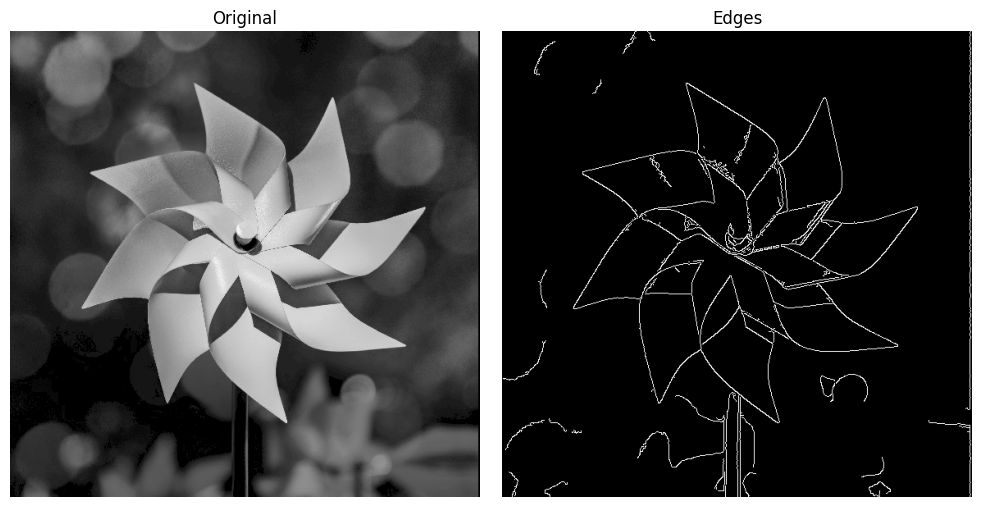

In [6]:
image_path = '../../edge_detection.png'
image = cv2.imread(image_path, 0)

edges = cv2.Canny(image, 50, 150)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Edges')
plt.axis('off')
plt.tight_layout()
plt.show()

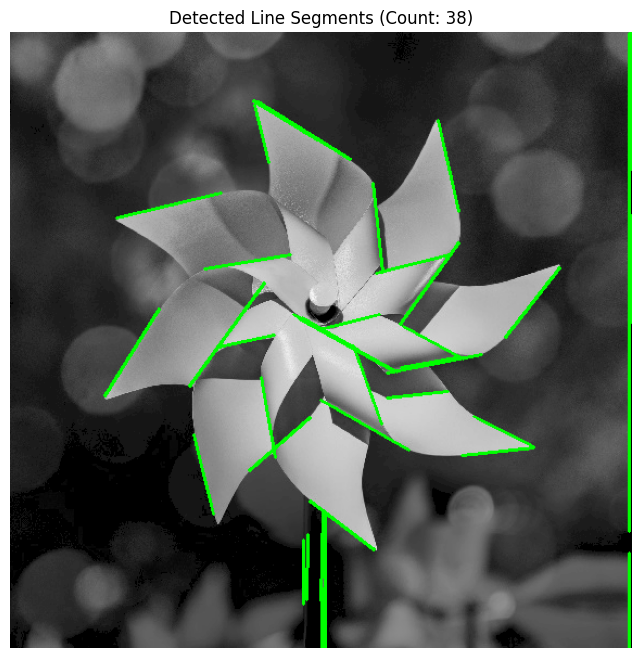

In [7]:
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=50, minLineLength=50, maxLineGap=10)

hough_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(hough_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(hough_image, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Line Segments (Count: {len(lines) if lines is not None else 0})')
plt.axis('off')
plt.show()

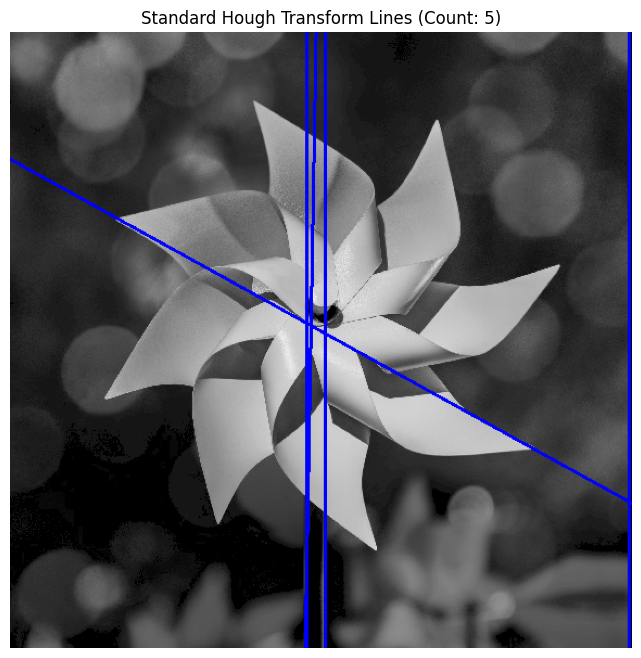

In [8]:
lines_standard = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=100)

hough_std = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

if lines_standard is not None:
    for line in lines_standard:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * a)
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * a)
        cv2.line(hough_std, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(hough_std, cv2.COLOR_BGR2RGB))
plt.title(f'Standard Hough Transform Lines (Count: {len(lines_standard) if lines_standard is not None else 0})')
plt.axis('off')
plt.show()